In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand
from scipy.optimize import curve_fit

<span style="font-size:16px">
    
# Self-Avoiding Random Walks
A self-avoiding random walk (SAW) describes the configurations of a polymer composed of a linear chain of monomers. Since two monomers cannot occupy the same space, the polymer cannot intersect itself. If we assign the $i$th monomer the coordinate $r_i$, then a linear chain with $L+1$ monomers can be described by the set of points $\{r_0, r_1, r_2, ... , r_L\}$. The only condition we need to apply to ensure that the polymer does not intersect with itself is $r_i \neq r_j$ for all $i\neq j$. 

Therefore, we can assemble the polymer monomer-by-monomer and only choose positions that have not been previously occupied. This is equivalent to running a random walk which cannot revisit any position - a self-avoiding random walk. Note that these walks are simply a subset of all free random walks, in which there are no intersections or "backtracking" (where $r_{i+2}=r_i$). 

However, even without backtracking, with 3 possible directions at every step, even a polymer of length $L=20$ will have $3^{20} \approx 10^9$ possible configurations. We therefore use a Monte-Carlo simulation to generate a large number of possible polymers and then determine their behaviour from their average.
</span>

<span style="font-size:16px">
    
## 1. Simple Sampling

To simulate a self-avoiding random walk, we can define a set of possible steps $\{(0, 1), (0, -1), (1, 0), (-1, 0)\}$ and choose a random direction from these at each step. To get correct statistics, we must consider all 4 possibilities equally and discard any chains that land on a previously visited site. With this method, we expect the mean square displacement to be given by: 

$$\displaystyle \langle r^2 \rangle = \frac{\sum_{k = 1}^N \ r_k^2}{N}$$

Where $r_k^2=|r_{k,L} - r_{k,0}|^2$ for the $k$th polymer. However, this method turns out to be highly inefficient for long chains since the proportion of discarded chains grows exponentially for longer chains. This has been tested below.

</span>

<span style="font-size:16px">
    
### Iterative SAW

I initially wrote an iterative program to generate independent "chains" using a loop that ran from $r_0$ to $r_L$ for each polymer. However, I realised that PERM requires a recursive format and modified my code to work accordingly. Ignore this program.
</span>

In [2]:
"""
    Self-Avoiding Random Walk (Using Simple Sampling)

    This is an iterative program that uses a for loop to generate an entire walk before moving to the next one. 
    I have used simple sampling, so all self-intersecting walks are discarded during the growing process.
    
    Parameters:
    - L: Length of polymer chain.
    - N: Number of chains to generate.

    Returns:
    - chain_k: List of successful polymer chains.
    - w_k: Weights of the successful chains.
"""

# Define possible moves: up, down, left, right
step = [(0, 1), (0, -1), (1, 0), (-1, 0)]

def saw_iter(L, N):
    chain_k = []

    # Check for duplicates 
    def is_duplicate(chain):
        return any(c == chain for c in chain_k)
        
    # Iteratively grow each chain
    for k in range(N):
        # Initialise chain at origin
        chain = [(0, 0)]     
        # Store visted positions
        visited = set(chain)  

        for i in range(1, L):
            # Choose next move
            dx, dy = rand.choice(step)
            r_i = (chain[-1][0] + dx, chain[-1][1] + dy)
            if r_i not in visited: 
                chain.append(r_i)
                visited.add(r_i)
            else:
                break

        # Store non-duplicate chains with length = L 
        if len(chain) == L and not is_duplicate(chain):
            chain_k.append(chain)

    return chain_k

In [3]:
# Run Simulation
L = 10 # Length of polymer chain
N = 10000 # Number of chains simulated

chain_k = saw_iter(L, N)

print(f'Number of chains simulated = {N}')
print(f'Number of chains generated = {len(chain_k)}')
print(f'Number of chains discarded = {N - len(chain_k)}')

Number of chains simulated = 10000
Number of chains generated = 635
Number of chains discarded = 9365


<span style="font-size:16px">

### Recursive SAW
</span>

In [9]:
"""
    Self-Avoiding Random Walk (Using Simple Sampling)

    This is a recursive program that uses a "grow" function recursively to add a step in each loop.
    I have used simple sampling, so all self-intersecting walks are discarded during the growing process.
    
    Parameters:
    - L: Length of polymer chain.
    - N: Number of chains to generate.

    Returns:
    - chain_k: List of successful polymer chains.
    - w_k: Weights of the successful chains.
"""

# Define possible moves: up, down, left, right
step = [(0, 1), (0, -1), (1, 0), (-1, 0)]

def saw_rec(L, N):
    chain_k = []
    chain_seen = set()

    # Recursively grow chain
    def grow(chain, visited):
        
        # Store non-duplicate chains with length = L 
        if len(chain) == L:
            chain_tuple = tuple(chain)
            if chain_tuple not in chain_seen:
                chain_k.append(chain)
                chain_seen.add(chain_tuple)
            return

        # Choose next move
        dx, dy = rand.choice(step)
        r_i = (chain[-1][0] + dx, chain[-1][1] + dy)
        if r_i not in visited: 
            chain.append(r_i)
            visited.add(r_i)
        else:
            return
        
        # Recursively continue growing
        grow(chain, visited)

    # Simulate N independent walks
    for k in range(N):
        # Initialise chain at origin
        chain = [(0, 0)]     
        # Store visted positions
        visited = set(chain)  
        
        grow(chain, visited)

    return chain_k

In [5]:
# Run Simulation
L = 10 # Length of polymer chain
N = 10000 # Number of chains simulated

chain_k = saw_rec(L, N)

print(f'Number of chains simulated = {N}')
print(f'Number of chains generated = {len(chain_k)}')
print(f'Number of chains discarded = {N - len(chain_k)}')

Number of chains simulated = 10000
Number of chains generated = 600
Number of chains discarded = 9400


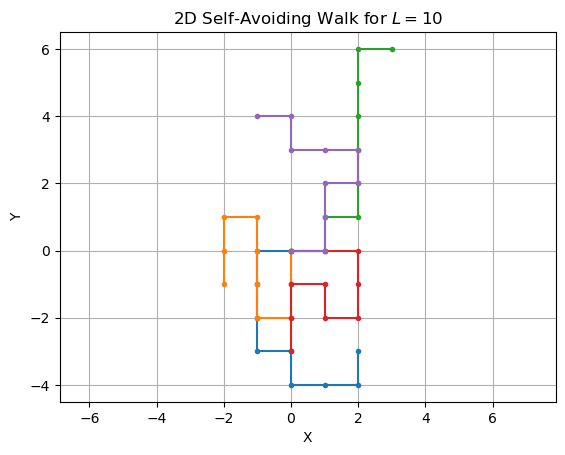

In [6]:
# Plot some chains
for i in range(5):
    x, y = zip(*chain_k[i])
    plt.plot(x, y, marker='o', ms=3)
plt.title(f'2D Self-Avoiding Walk for $L={L}$')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True)
plt.show()

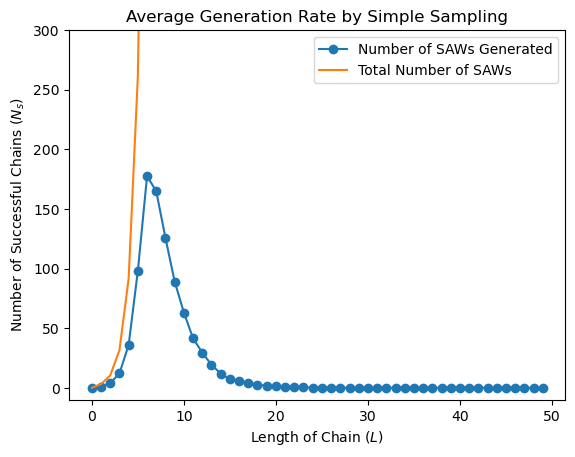

In [7]:
# Generation Rate
L_max = 50
chain_avg = []

for trials in range(20):
    num_chains = np.zeros(L_max)
    for L in range(1, L_max):
        N = 1000
        chain_k = saw_rec(L, N)
        num_chains[L] = len(chain_k)
    chain_avg.append(num_chains)

def expected(x):
    A = 1.17704242
    G = 43/32
    Mu = 2.638
    return A*(Mu**x)*(x**(G-1))

Lengths = np.arange(L_max)

plt.plot(Lengths, np.mean(chain_avg, axis=0), marker='o', label='Number of SAWs Generated')
plt.plot(Lengths, expected(Lengths), label='Total Number of SAWs')
plt.ylim(-10, 300)
plt.xlabel('Length of Chain ($L$)')
plt.ylabel('Number of Successful Chains ($N_s$)')
plt.title('Average Generation Rate by Simple Sampling')
plt.legend()
plt.show()

<span style="font-size:16px">

## 2. Rosenbluth & Rosenbluth (RR) Method
To improve on simple sampling, the RR method determines the unoccupied positions $m_i$ (on a square lattice, this can have the values 0, 1, 2 or 3) adjacent to $r_{i-1}$ and places the monomer $r_i$ at one of those positions at random. Since it is possible to encounter a dead end where $m_i=0$, the chain cannot be grown further and must be discarded. 

<center><img src="../Computational Physics/SAW_growing.jpeg" width="500" /></center>

If the process is repeated $N$ times, the $k$th polymer occupies the positions $\{r_{k,0}, r_{k,1}, r_{k,2}, ... , r_{k,L}\}$ and is associated with a number of available neighbors at each step $\{m_{k,0}, m_{k,1}, m_{k,2}, ... , m_{k,L}\}$. We record this information in form of a "weight": 

$$\displaystyle w_k = \prod_{i=1}^L m_{k,i}$$

Note that our walk is biased by our availability of neighbours at each step, so the probability of getting any given chain is:

$$\displaystyle P(k) = \prod_{i=1}^L \frac{1}{m_{k,i}} = \frac{1}{w_k}$$

Hence, any observable $A$ is found using a weighted average to balance the statistics: 

$$\displaystyle \langle A \rangle = \frac{\sum_{k = 1}^N w_k \ A_k}{\sum_{k = 1}^N w_k}$$

Where $w_k$ is the weight of the $k$th chain. 
</span>

In [8]:
"""
    Self-Avoiding Random Walk (Using RR Method)

    This is a recursive program that uses a "grow" function recursively to add a step at each loop.
    I have used RR sampling, so steps are chosen only from available neighbours and the corresponding weights are found.
    
    Parameters:
    - L: Length of polymer chain.
    - N: Number of chains to generate.

    Returns:
    - chain_k: List of successful polymer chains.
    - w_k: Weights of the successful chains.
"""

# Define possible moves: up, down, left, right
step = [(0, 1), (0, -1), (1, 0), (-1, 0)]

def saw_RR(L, N):
    chain_k = []
    w_k = []
    chain_seen = set()
        
    # Recursive growth
    def grow(chain, visited, w):

        # Store non-duplicate chains with length = L 
        if len(chain) == L:
            chain_tuple = tuple(chain)
            if chain_tuple not in chain_seen:
                chain_k.append(chain.copy())
                w_k.append(w)
                chain_seen.add(chain_tuple)
            return

        # Determine available moves
        neighbors = []
        for dx, dy in step:
            r = (chain[-1][0] + dx, chain[-1][1] + dy)
            if r not in visited:
                neighbors.append(r)

        m = len(neighbors)

        # Dead end: discard chain
        if m == 0:
            return

        # Update weight
        w_new = w*m

        # Choose next move
        r_i = rand.choice(neighbors)
        chain.append(r_i)
        visited.add(r_i)
        
        # Recursively continue growing with new weight
        grow(chain, visited, w_new)

    # Simulate N independent walks
    for k in range(N):
        chain = [(0, 0)]     
        w = 1            
        visited = set(chain)  
        
        grow(chain, visited, w)

    return chain_k, w_k

In [9]:
# Run Simulation
L = 10 # Length of polymer chain
N = 1000 # Number of chains simulated

chain_k, w_k = saw_RR(L, N)

print(f'Number of chains simulated = {N}')
print(f'Number of chains generated = {len(chain_k)}')
print(f'Number of chains discarded = {N - len(chain_k)}')

Number of chains simulated = 1000
Number of chains generated = 958
Number of chains discarded = 42


slope = 1.450


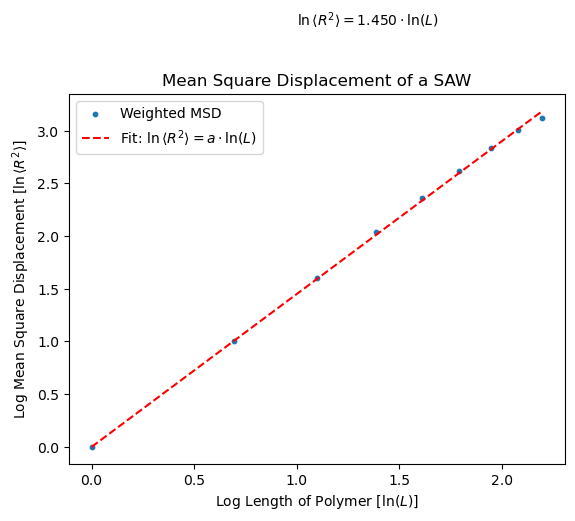

In [10]:
# Mean Square Displacement 
R = []
for k in range(len(chain_k)): 
    x, y = zip(*chain_k[k])
    R.append(np.array(x)**2 + np.array(y)**2)

# Weighted Average
msd = np.average(R, axis=0, weights=w_k)
l = np.arange(len(msd))

# Log transform
log_msd = np.log(np.array(msd[1:], dtype=np.float64))
log_l = np.log(l[1:])

# Curvefit
def msd_fit(x, a):
    return a*x

par, cov = curve_fit(msd_fit, log_l, log_msd)

print(f'slope = {par[0]:.3f}')

plt.scatter(log_l, log_msd, s=10, label='Weighted MSD')
plt.plot(log_l, msd_fit(log_l, par[0]), ls='--', c='red', label=rf'Fit: $\ln\langle R^2\rangle = a\cdot\ln(L)$')
plt.text(1, 4, rf'$\ln\langle R^2 \rangle = {par[0]:.3f}\cdot\ln(L)$')
plt.xlabel('Log Length of Polymer [$\ln(L)$]')
plt.ylabel(r'Log Mean Square Displacement [$\ln\langle R^2\rangle$]')
plt.title(r'Mean Square Displacement of a SAW')
plt.legend()
plt.show()

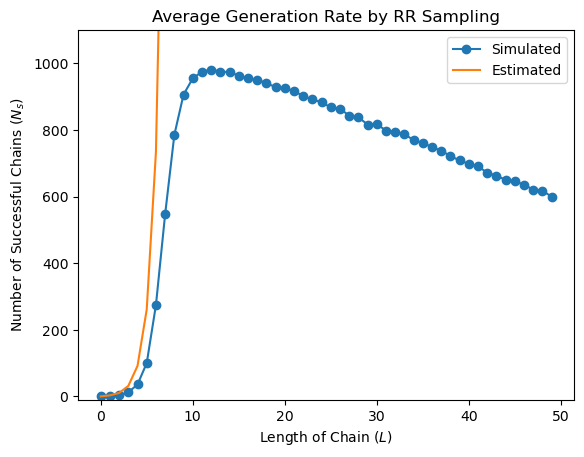

In [11]:
# Generation Rate
L_max = 50
chain_avg = []

for trials in range(10):
    num_chains = np.zeros(L_max)
    for l in range(1, L_max):
        chain_k, w_k = saw_RR(l, 1000)
        num_chains[l] = len(chain_k)
    chain_avg.append(num_chains)

def expected(x):
    A = 1.17704242
    G = 43/32
    Mu = 2.638
    return A*(Mu**x)*(x**(G-1))

Lengths = np.arange(L_max)

plt.plot(Lengths, np.mean(chain_avg, axis=0), marker='o', label='Simulated')
plt.plot(Lengths, expected(Lengths), label='Estimated')
plt.ylim(-10, 1100)
plt.xlabel('Length of Chain ($L$)')
plt.ylabel('Number of Successful Chains ($N_s$)')
plt.title('Average Generation Rate by RR Sampling')
plt.legend()
plt.show()

<span style="font-size:16px">
    
## 3. Pruned-Enriched Rosenbluth Method (PERM)
The search for possible configurations can be further improved by "pruning" walks with low weight and "enriching" walks with high weight since they are more likely to lead a complete self-avoiding walk. The procedure for pruning and enriching is: 

1. **Pruning**: If $w_k < W_-$, the polymer is either discarded with a $50\%$ probability, or the weight it doubled ($w'_k = 2w_k$). This reduces the number of unpromising polymers which have low weightage, reducing time wasted on terminating walks. Discarding half the polymers and doubling the weight of the other half ensures that the weighted average is unaffected. 

2. **Enriching**: If $w_k > W_+$, the polymer is copied and both the original and copy are assigned half the weight ($w'_k = w_k/2$). This increases the number of promising polymers which have high weightage, exploring more self-avoiding walks simultaneously. Copying the polymer and halving their weight also ensures that the weighted average is unaffected.

The thresholds $W_-$ and $W_+$ can be arbitrarily chosen to control the extent of pruning and enriching. Grassberger (1997) who suggested PERM recommended choosing $W_+ = c\bar{W}$ and $W_- = \bar{W}/c$ where $\bar{W}$ is the average weight and $c^2\approx 10$. To begin with, I have chosen $c=3$.

<center><img src="../Computational Physics/perm flowchart.png" width="1100" /></center>

</span>

### Recursive SAW with PERM

In [6]:
"""
    Self-Avoiding Random Walk (Using PERM)

    This is a recursive program that uses a "grow" function recursively to add a step at each loop.
    I have PERM to enhance the number of successful walks found by pruning low weight walks and enrinching high weight walks.
    
    Parameters:
    - L: Length of polymer chain.
    - N: Number of chains to generate.

    Returns:
    - chain_k: List of successful polymer chains.
    - w_k: Weights of the successful chains.
"""

# Define possible moves: up, down, left, right
step = [(0, 1), (0, -1), (1, 0), (-1, 0)]

def saw_perm(L, N, c):
    chain_k = []
    w_k = []
    weights = [[] for _ in range(L + 1)]
    weight_sum = np.zeros(L+1)
    weight_count = np.zeros(L+1)
    chain_seen = set()
    tour_avg_weights = []
        
    # Recursive growth
    def grow(chain, visited, w, tour_w):

        # Maximum walks generated
        if len(chain_k) == 1000:
            return

        # Store weight at current step
        l = len(chain)
        weights[l].append(w)

        # Store non-duplicate chains with length = L 
        if l == L:
            chain_tuple = tuple(chain)
            if chain_tuple not in chain_seen:
                chain_k.append(chain.copy())
                w_k.append(w)
                tour_w.append(w)
                chain_seen.add(chain_tuple)
            return

        # Determine available moves
        neighbors = []
        for dx, dy in step:
            r = (chain[-1][0] + dx, chain[-1][1] + dy)
            if r not in visited:
                neighbors.append(r)

        m = len(neighbors)

        # Dead end: discard chain
        if m == 0:
            return

        # Update weight
        w_new = w*m

        # Determine thresholds
        w_avg = np.mean(weights[l])
        W_plus = w_avg*c
        W_minus = w_avg/c

        # Pruning
        if w_new < W_minus:
            if rand.random() > 0.5:
                return
            else:
                w_new *= 2  # Double the weight and continue

        # Enrichment
        elif w_new > W_plus:
            for copies in range(2):
                r_i = rand.choice(neighbors)
                chain.append(r_i)
                visited.add(r_i)
                
                grow(chain, visited, w_new / 2, tour_w) # Half the weight and continue

                # Backtrack and continue
                visited.remove(r_i)
                chain.pop()
            return
            
        # Choose next move
        r_i = rand.choice(neighbors)
        chain.append(r_i)
        visited.add(r_i)
        
        # Recursively continue growing with new weight
        grow(chain, visited, w_new, tour_w)

        # Backtrack one step to explore alternate paths
        visited.remove(r_i)
        chain.pop()

    # Simulate N independent walks
    for k in range(N):
        chain = [(0, 0)]     
        w = 1            
        visited = set(chain)  

        tour_w = []

        grow(chain, visited, w, tour_w)

        if tour_w:
            tour_avg_w = np.mean(tour_w)
            tour_avg_weights.append(tour_avg_w)

    return chain_k, w_k, tour_avg_weights

In [4]:
# Run Simulation
L = 50 # Length of polymer chain
N = 1000 # Number of chains simulated
c = 5 # Pruning/enrichment parameter

chain_k, w_k, tour_weights = saw_perm(L, N, c)

print(f'Number of chains simulated = {N}')
print(f'Number of chains generated = {len(chain_k)}')

Number of chains simulated = 1000
Number of chains generated = 2678


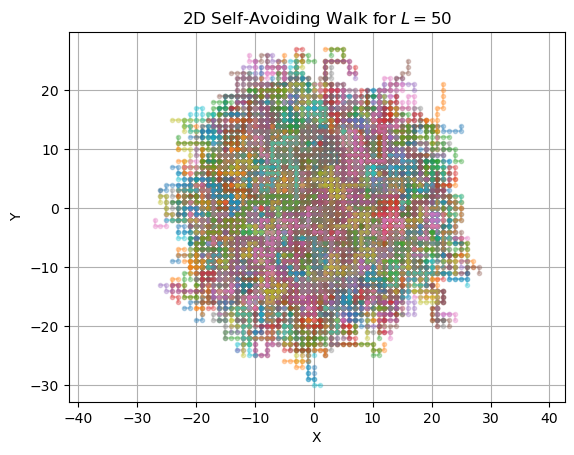

In [5]:
# Plot some chains
for i in range(len(chain_k)):
    x, y = zip(*chain_k[i])
    plt.plot(x, y, alpha=0.3, marker='o', ms=3, label=f'Chain {i+1}')
plt.title(f'2D Self-Avoiding Walk for $L={L}$')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.grid(True)
plt.show()

<span style="font-size:16px">
    
## Results
</span>

<span style="font-size:16px">
    
### 1. Number of SAWs

Interestingly, there is no closed form equation to determine the total number of possible SAWs for a given polymer length $L$. Iwan Jensen (2013) devised an algorithm to enumerate the number self-avoiding walks for a given length. He spent $\sim 16,500$ CPU hours to generate the number of walks up to $L=79$ (I have included the first 20 below).

| Length | Number of Walks |
|-------|------------|
| 0     | 1          |
| 1     | 4          |
| 2     | 12         |
| 3     | 36         |
| 4     | 100        |
| 5     | 284        |
| 6     | 780        |
| 7     | 2,172       |
| 8     | 5,916       |
| 9     | 16,268      |
| 10    | 44,100      |
| 11    | 120,292     |
| 12    | 324,932     |
| 13    | 881,500     |
| 14    | 2,374,444    |
| 15    | 6,416,596    |
| 16    | 17,245,332   |
| 17    | 46,466,676   |
| 18    | 124,658,732  |
| 19    | 335,116,620  |
| 20    | 897,697,164  |

Clearly the number of walks blows up very quickly. The estimated number of walks $n_L$ for a walk of length $L$ is:

$$\displaystyle n_L \approx A\mu^L L^{\gamma-1}$$

Where $A \approx 1.17704242$, $\mu \approx 2.638$ and $\gamma = 43/32$. I have used this to plot the estimated number of walks in all the average generation rate graphs. By running multiple trials across all three methods, I found that PERM produces the most walks for a given number of simulations.

</span>

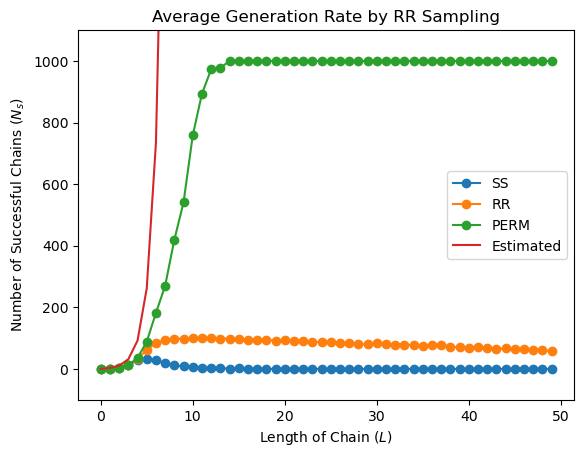

In [10]:
# Generation Rate
L_max = 50
SS_avg = []
RR_avg = []
PERM_avg = []

for trials in range(5):
    num_SS = np.zeros(L_max)
    num_RR = np.zeros(L_max)
    num_PERM = np.zeros(L_max)
    
    for l in range(1, L_max):
        chain_SS = saw_rec(l, 100)
        num_SS[l] = len(chain_SS)
        
        chain_RR, w_RR = saw_RR(l, 100)
        num_RR[l] = len(chain_RR)
        
        chain_PERM, w_PERM, tour_w_PERM = saw_perm(l, 100, 3)
        num_PERM[l] = len(chain_PERM)
        
    SS_avg.append(num_SS)
    RR_avg.append(num_RR)
    PERM_avg.append(num_PERM)

def expected(x):
    A = 1.17704242
    G = 43/32
    Mu = 2.638
    return A*(Mu**x)*(x**(G-1))

Lengths = np.arange(L_max)

plt.plot(Lengths, np.mean(SS_avg, axis=0), marker='o', label='SS')
plt.plot(Lengths, np.mean(RR_avg, axis=0), marker='o', label='RR')
plt.plot(Lengths, np.mean(PERM_avg, axis=0), marker='o', label='PERM')
plt.plot(Lengths, expected(Lengths), label='Estimated')
plt.ylim(-100, 1100)
plt.xlabel('Length of Chain ($L$)')
plt.ylabel('Number of Successful Chains ($N_s$)')
plt.title('Average Generation Rate by RR Sampling')
plt.legend()
plt.show()

<span style="font-size:16px">
    
### 2. Mean Square Displacement and Radius of Gyration
For a self-avoiding random walk, the end-to-end distance ($r_e$) is given by $r_e^2=|r_{k,L} - r_{k,0}|^2$. The mean of the displacement square is an observable and, as mentioned previously, it can be found using a weighted average: 

$$\displaystyle \langle r_e^2 \rangle = \frac{\sum_{k = 1}^N w_k \ r_k^2}{\sum_{k = 1}^N w_k}$$

Where $w_k$ is the weight of the $k$th chain. As seen in other random walks, this value has a power law scaling with the length of the walk $L$: 

$$\displaystyle \langle r_e^2 \rangle \sim L^{2\nu}$$

Where $\nu = 3/4$ for 2D, and $\nu = 3/5$ for 3D.

We can also use the radius of gyration that is given by: 

$$\displaystyle r_g^2 = \frac{1}{L+1}\sum_{i = 0}^L |r_i - r_{cm}|^2$$

Where $r_{cm} = \frac{1}{L+1}\sum_{i = 0}^L r_i$ is the position of the "center of mass". The mean square radius of gyration follows the same relationship with walk length: 

$$\displaystyle \langle r_g^2 \rangle \sim L^{2\nu}, \ \nu_{2D} = 3/4, \ \nu_{3D} = 3/5 $$

In my case, I have fitted a function of the form $\ln\langle r^2 \rangle = \alpha\ln(L)+\beta$ to the simulation data, so that I can expect $\alpha\approx 1.5$ for my 2D SAW for both mean square displacement and radius of gyration.
</span>

slope = 1.506


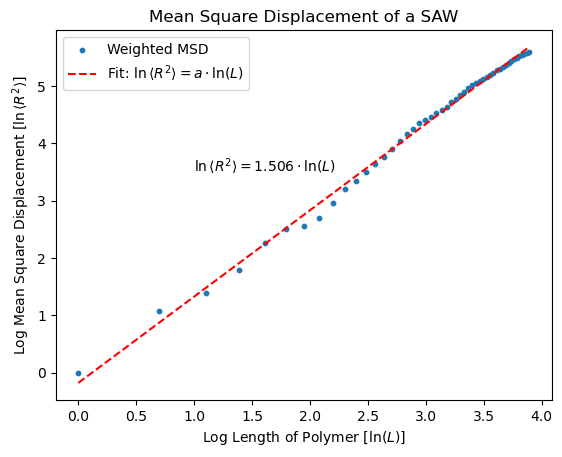

In [17]:
# Mean Square Displacement 
L = 50 # Length of polymer chain
N = 1000 # Number of chains simulated
c = 3 # Pruning/enrichment parameter

# Run simulation
chain_k, w_k, tour_weights = saw_perm(L, N, c)

R = []
for chain in chain_k: 
    x, y = zip(*chain)
    R.append(np.array(x)**2 + np.array(y)**2)

# Weighted Average
msd = np.average(R, axis=0, weights=w_k)
l = np.arange(len(msd))

# Log transform
log_msd = np.log(np.array(msd[1:], dtype=np.float64))
log_l = np.log(l[1:])

# Curvefit
p, q = np.polyfit(log_l, log_msd, 1)

print(f'slope = {p:.3f}')

plt.scatter(log_l, log_msd, s=10, label='Weighted MSD')
plt.plot(log_l, p*log_l+q, ls='--', c='red', label=rf'Fit: $\ln\langle R^2\rangle = a\cdot\ln(L)$')
plt.text(1, 3.5, rf'$\ln\langle R^2 \rangle = {p:.3f}\cdot\ln(L)$')
plt.xlabel('Log Length of Polymer [$\ln(L)$]')
plt.ylabel(r'Log Mean Square Displacement [$\ln\langle R^2\rangle$]')
plt.title(r'Mean Square Displacement of a SAW')
plt.legend()
plt.show()

slope = 1.372


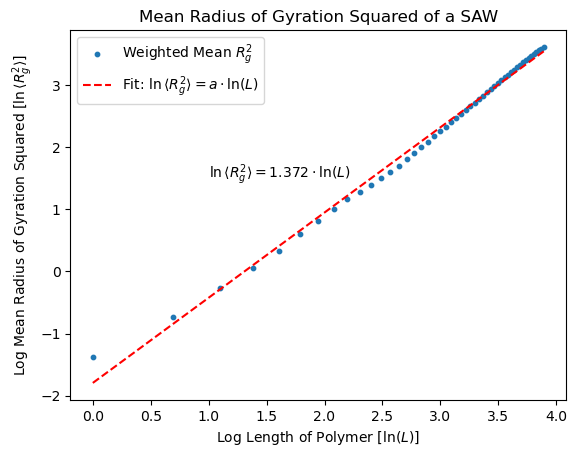

In [20]:
# Radius of Gyration
L = 50 # Length of polymer chain
N = 1000 # Number of chains simulated
c = 3 # Pruning/enrichment parameter

# Run simulation
chain_k, w_k, tour_weights = saw_perm(L, N, c)

Rg = [[] for k in range(len(chain_k))]
for k in range(len(chain_k)):
    x, y = zip(*chain_k[k])
    x = np.array(x)
    y = np.array(y)

    for i in range(1, len(x)+1):
        x_cm = np.mean(x[:i])
        y_cm = np.mean(y[:i])

        Rg[k].append(np.mean((x[:i] - x_cm)**2 + (y[:i] - y_cm)**2))

Rg_avg = np.average(Rg, axis=0, weights=w_k)
l = np.arange(len(Rg_avg))

log_l = np.log(l[1:])
log_Rg = np.log(np.array(Rg_avg[1:], dtype=np.float64))

# Curvefit
p, q = np.polyfit(log_l, log_Rg, 1)

print(f'slope = {p:.3f}')

plt.scatter(log_l, log_Rg, s=10, label=r'Weighted Mean $R_g^2$')
plt.plot(log_l, p*log_l+q, ls='--', c='red', label=rf'Fit: $\ln\langle R_g^2\rangle = a\cdot\ln(L)$')
plt.text(1, 1.5, rf'$\ln\langle R_g^2 \rangle = {p:.3f}\cdot\ln(L)$')
plt.xlabel('Log Length of Polymer [$\ln(L)$]')
plt.ylabel(r'Log Mean Radius of Gyration Squared [$\ln\langle R_g^2\rangle$]')
plt.title(r'Mean Radius of Gyration Squared of a SAW')
plt.legend()
plt.show()

<span style="font-size:16px">

### 3. Weight Distribution
Since the walks produced by PERM are not uncorrelated, excessive pruning and enriching can lead to statistically biased results. Multiple walks may share the same ancestor and the set of all these correlated walks are known as a "tour". One way to test for correlation is to plot a histogram of the log of *tour* weights $P[\ln(W)]$ and $W*P[\ln(W)]$. If $W*P[\ln(W)]$ has its maximum, at a value of $\ln(W)$ where the distribution $P[\ln(W)]$ is well sampled, we are on the safe side. If not, then the results can still be correct, but we have no guarantee for it.

<center><img src="../Computational Physics/histograms.png" width="300" /></center>

</span>

<span style="font-size:16px">
    
## Acknowledgements and References
This project would not have been possible without Professor Somen's inputs and the TU-Delft Computational Physics lecture notes on PERM. I would also like to thank all my other classmates, especially Ayush Gurule, for their help and support. I have used the assistance of Chat-GPT to understand some parts of the algorithm and to debug my code wherever needed.

1. Simulating polymers as self-avoiding random walks - Computational Physics. (2020). Delft University of Technology. https://compphys.quantumtinkerer.tudelft.nl/proj2-polymers/
2. Grassberger, P. (1997). Pruned-enriched Rosenbluth method: Simulations of θ-polymers of chain length up to 1,000,000. Physical Review. E, Statistical Physics, Plasmas, Fluids, and Related Interdisciplinary Topics, 56(3), 3682–3693. https://doi.org/10.1103/physreve.56.3682
3. Rosenbluth, M. N., & Rosenbluth, A. W. (1955). Monte Carlo calculation of the average extension of molecular chains. The Journal of Chemical Physics, 23(2), 356–359. https://doi.org/10.1063/1.1741967
4. Jensen, I. (2013). A new transfer-matrix algorithm for exact enumerations: self-avoiding walks on the square lattice. arXiv (Cornell University). https://doi.org/10.48550/arxiv.1309.6709
5. Hsu, H., & Grassberger, P. (2011). A Review of Monte Carlo Simulations of Polymers with PERM. Journal of Statistical Physics, 144(3), 597–637. https://doi.org/10.1007/s10955-011-0268-x
6. Combe, N., Vlugt, T. J. H., Wolde, P. R. T., & Frenkel, D. (2003). Dynamic pruned-enriched Rosenbluth method. Molecular Physics, 101(11), 1675–1682. https://doi.org/10.1080/0026897031000094461

</span>